In [2]:
from pathlib import Path 

import cv2 
import pandas as pd
import numpy as np
import IPython
from skimage import io

from videotools.detectors.face.yunet import Yunet

In [3]:
fd = Yunet()

In [4]:
def draw_faces(image, faces, draw_landmarks):
    for face in faces:
        # バウンディングボックス
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (face['x1'], face['y1']), (face['x2'], face['y2']), color, thickness, cv2.LINE_AA)

        if draw_landmarks:
            # ランドマーク（右目、左目、鼻、右口角、左口角）
            landmarks = face['landmarks']
            for landmark in landmarks:
                radius = 5
                thickness = -1
                cv2.circle(image, landmark, radius, color, thickness, cv2.LINE_AA)
            
        # 信頼度
        confidence = face['confidence']
        confidence = "{:.2f}".format(confidence)
        position = (face['x1'], face['y1'] - 10)
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 0.5
        thickness = 2
        cv2.putText(image, confidence, position, font, scale, color, thickness, cv2.LINE_AA)

In [5]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [6]:
def show_by_name(name):
    fp = Path('../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    show_image(img)

In [7]:
def show_faces(image, faces, draw_landmarks=True):
    draw_faces(image, faces, draw_landmarks=draw_landmarks)
    show_image(image)

In [8]:
def draw_faces_from_file(df, src):
    temp = df[(df['name'] == src) &
              (df['x1'].notna())]
    image = cv2.imread(f'../test_images/{src}')
    for idx, row in temp.iterrows():
        cv2.rectangle(image, (int(row['x1']), int(row['y1'])), (int(row['x2']), int(row['y2'])), (0, 0, 255), 2)
    show_image(image)

In [9]:
faces_df = pd.read_csv('../data/faces.csv', index_col=0)
faces_df.head()

,name,img_height,img_width,x1,y1,x2,y2,width,height,area,pct_of_frame,face_num
0,Billions.S01E02.1080p.BluRay.x265-RARBG_40128.png,1080.0,1920.0,323.0,5.0,919.0,731.0,596.0,726.0,432696.0,0.208669,0.0
1,Billions.S01E09.1080p.BluRay.x265-RARBG_52704.png,1080.0,1920.0,262.0,42.0,614.0,507.0,352.0,465.0,163680.0,0.078935,0.0
2,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,484.0,389.0,671.0,617.0,187.0,228.0,42636.0,0.020561,0.0
3,Billions.S01E10.1080p.BluRay.x265-RARBG_51504.png,1080.0,1920.0,1003.0,42.0,1195.0,261.0,192.0,219.0,42048.0,0.020278,1.0
4,Billions.S01E12.1080p.BluRay.x265-RARBG_78336.png,1080.0,1920.0,1121.0,66.0,1662.0,824.0,541.0,758.0,410078.0,0.197761,0.0


In [10]:
# fd = FaceDetectorYunet()

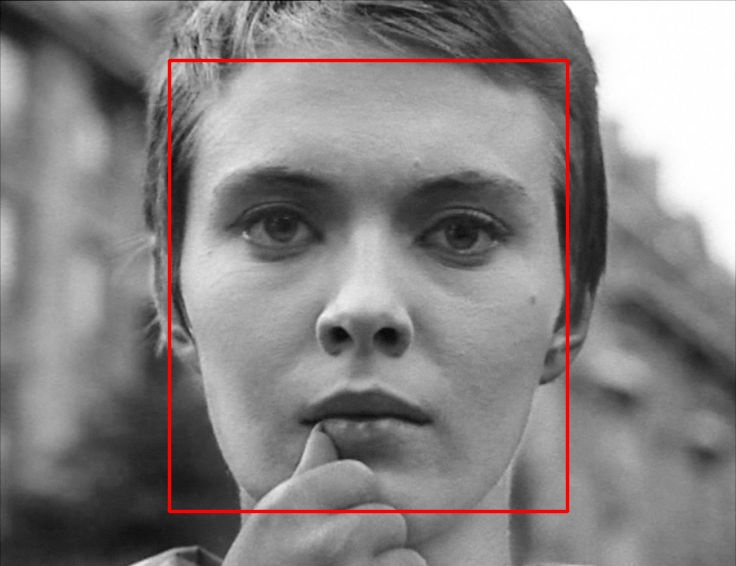

In [16]:
# org = cv2.imread('./images/img_1.jpg')
img = io.imread('https://github.com/astaileyyoung/CineFace/blob/main/research/notebooks/images/img_1.jpg?raw=true')
# img = cv2.resize(org, (300, 300))
faces = fd.predict(img)
image = fd.draw_faces(img, faces)
show_image(image)

In [11]:
faces

[{'x1': 169,
  'y1': 60,
  'x2': 567,
  'y2': 511,
  'face_num': 0,
  'landmarks': {'left_eye': [109, 124],
   'right_eye': [186, 126],
   'nose': [144, 173],
   'right_mouth': [116, 210],
   'left_mouth': [178, 211]},
  'confidence': 0.926667,
  'model': 'yunet',
  'img_width': 736,
  'img_height': 566,
  'face_width': 397.43999999999994,
  'face_height': 450.91333333333336,
  'area': 179210.99519999998,
  'pct_of_frame': 0.4301999999999999}]

In [50]:
name = 'The.X-Files.S07E17.all.things.1080p.BluRay.10Bit.Dts-HDMa5.1.HEVC-d3g_18624.png'

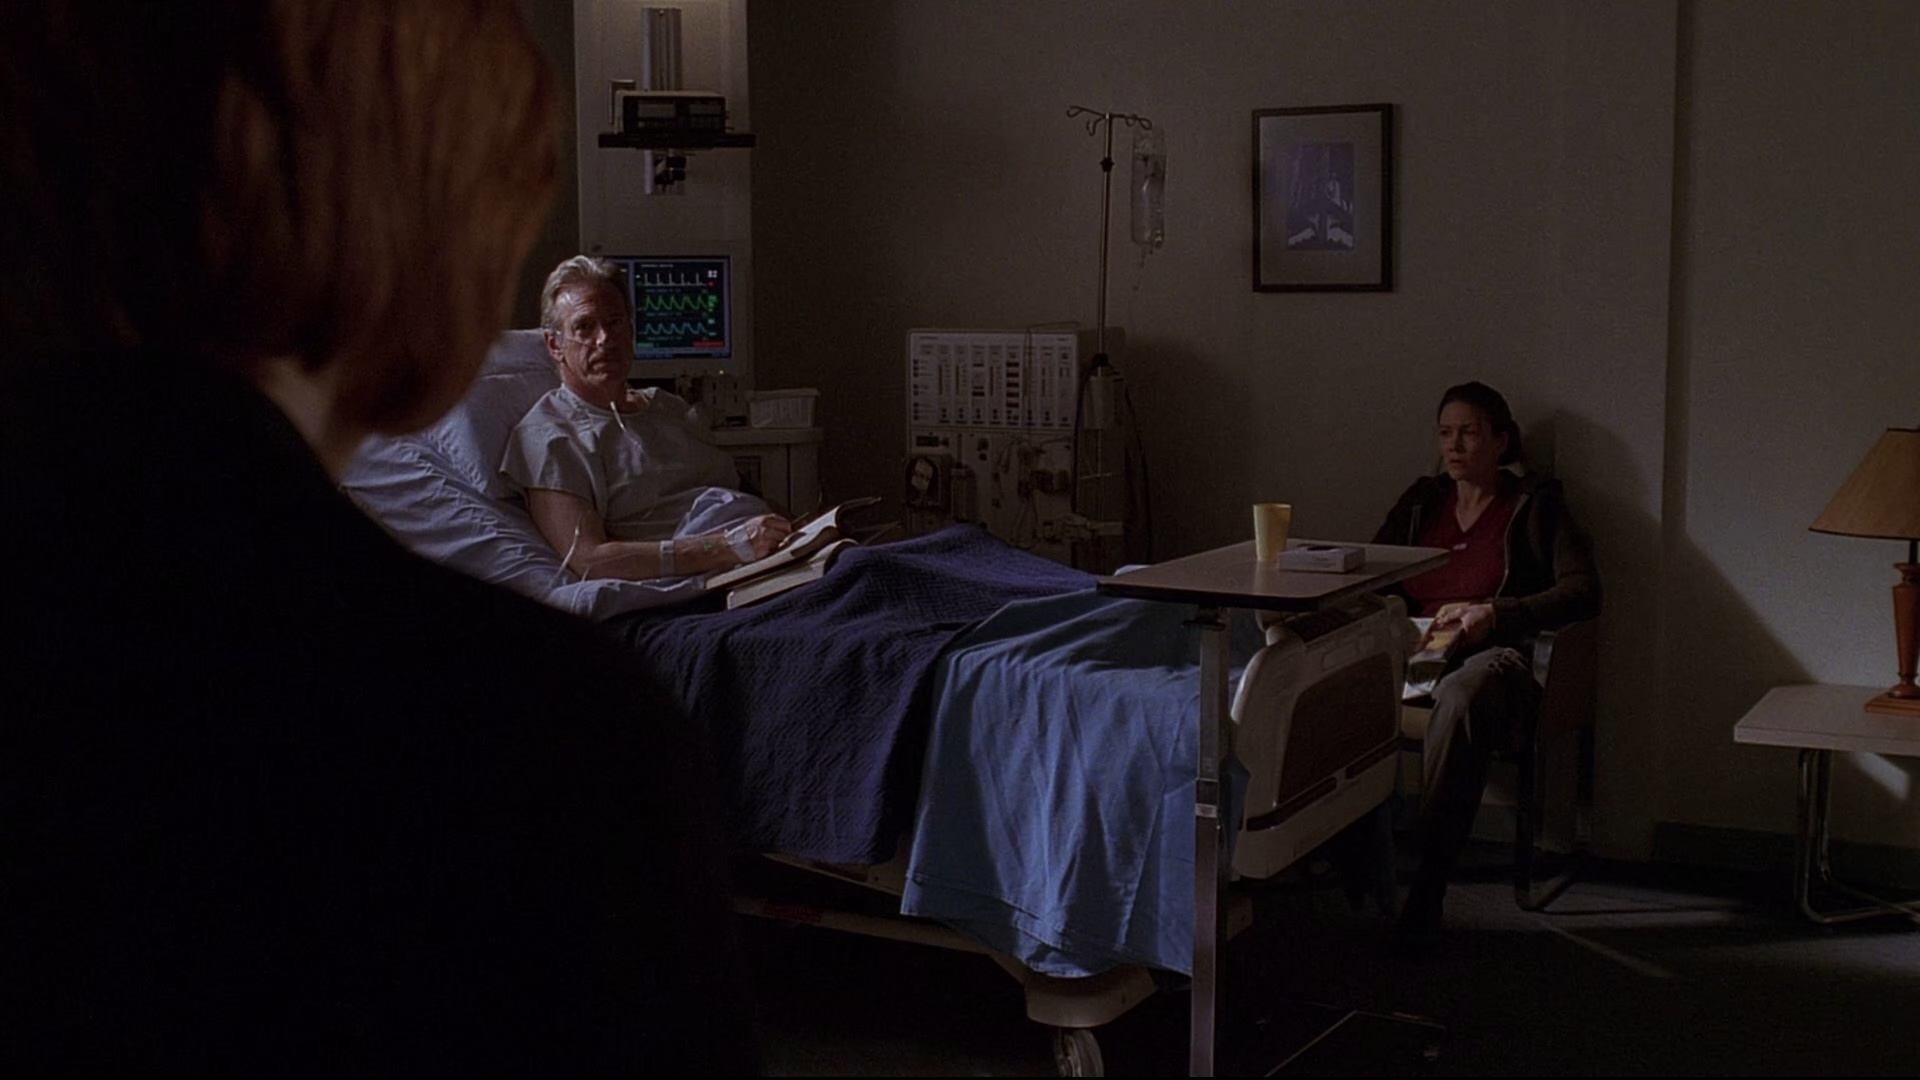

In [51]:
img = cv2.imread(f'../test_images/{name}')
faces = fd.detect(img)
if faces:
    fd.draw_faces(img, faces)
show_image(img)

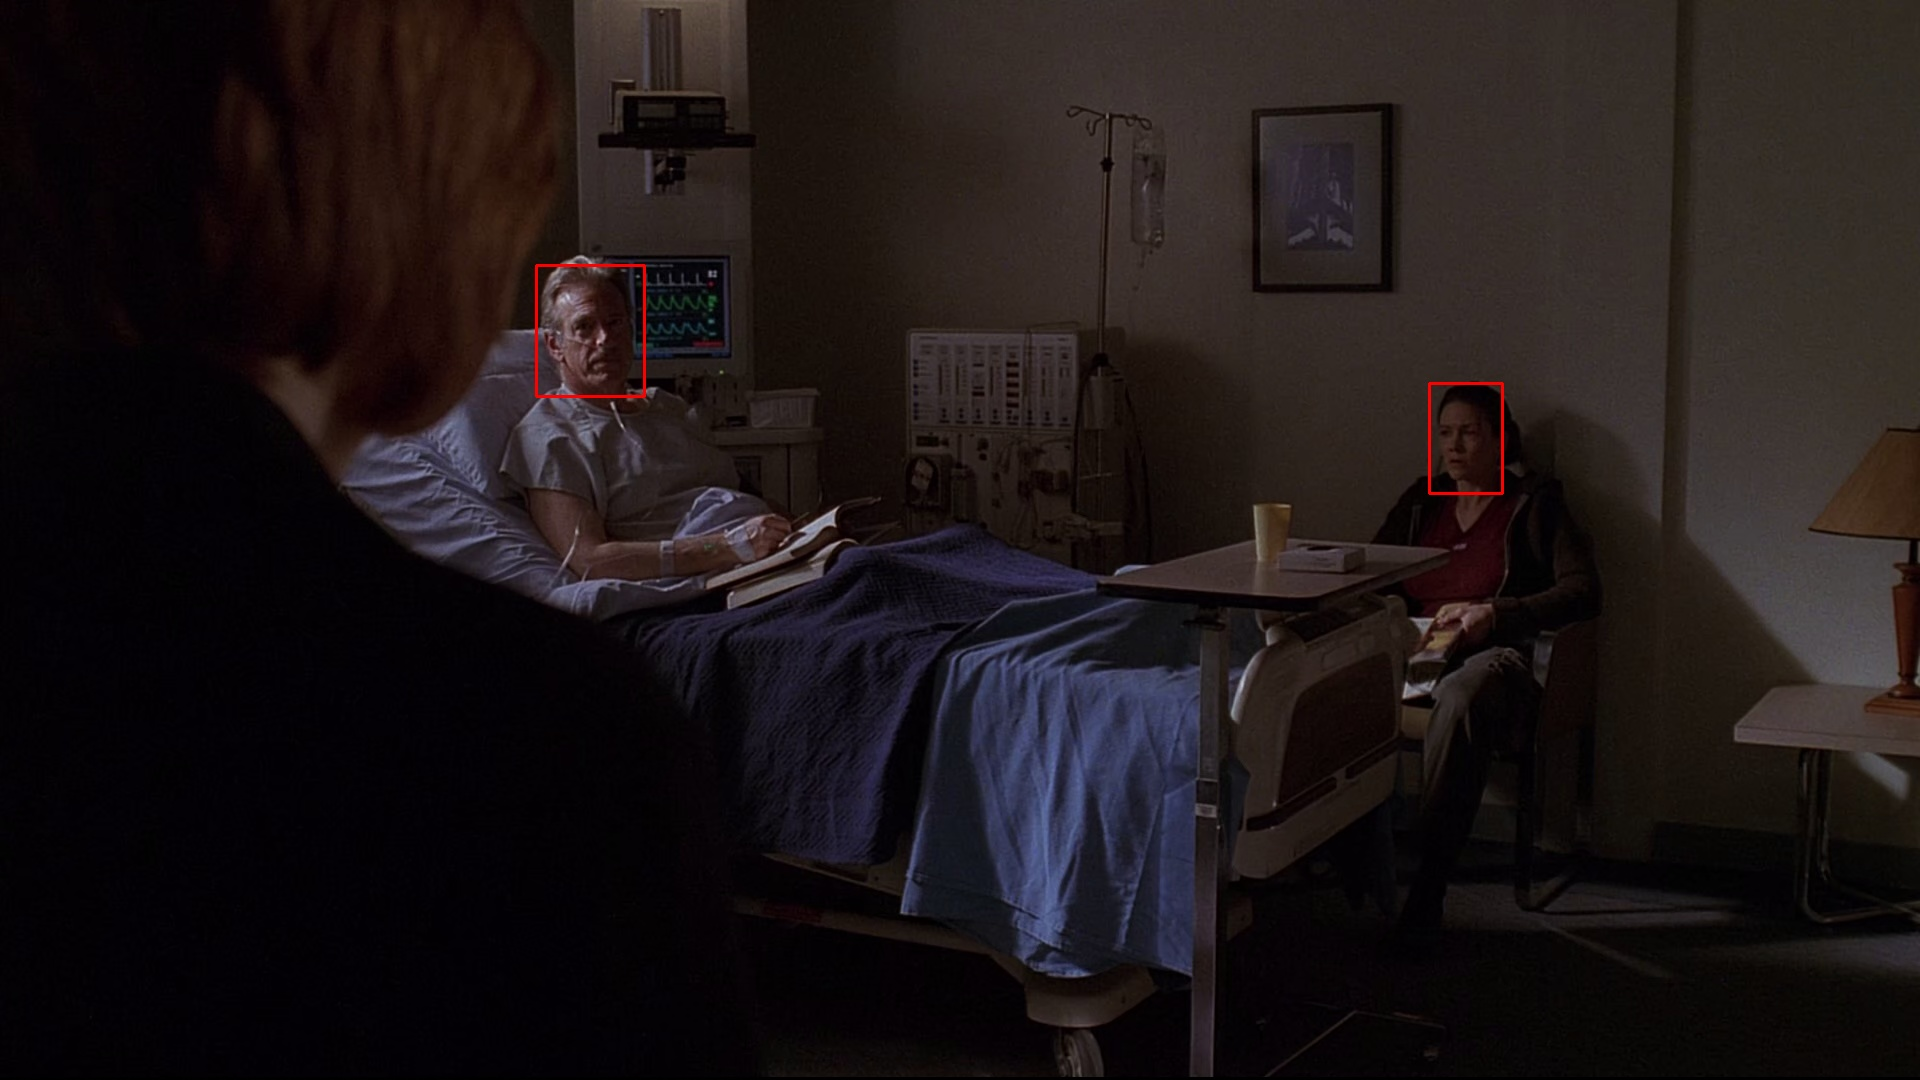

In [52]:
draw_faces_from_file(faces_df, name)